## Projekt 2 - Analiza dynamiki czoła lodowca Kronebreen (Svalbard) za pomocą wskaźnika NDSI

### Wymagania projektowe i punktacja (20 pkt)
  
Celem projektu jest przygotowanie interaktywnego "podręcznika" („How-To”) w formie Jupyter Notebooka, w którym krok po kroku przeprowadzicie użytkownika przez pełen proces pobierania, przetwarzania i wizualizacji wybranej analizy na danych satelitarnych dostarczanych przez Microsoft Planetary Computer.
  
1. **Parametryzacja notebooka** (2 pkt)  
   - Sekcja na początku z definiowanymi zmiennymi:
     - `bbox = [xmin, ymin, xmax, ymax]`  
     - `date_range = "YYYY-MM-DD/YYYY-MM-DD"`  
     - opcjonalne filtry (jeśli potrzebne w analizie)  
   - Kod automatycznie odwołuje się do tych zmiennych, bez ręcznej edycji w dalszej części.

2. **Opis wybranej kolekcji** (2 pkt)  
   - Nazwa i charakterystyka kolekcji (sensor, rozdzielczość, typ produktu).  
   - Link do katalogu Planetary Computer.  
   - Uzasadnienie wyboru tej kolekcji dla wybranego scenariusza.

3. **Scenariusz analizy** (2 pkt)  
   - Jasne sformułowanie celu / pytania badawczego.  
   - Krótki opis metody np.:  
     - wzór na wskaźnik (np. NDVI, mNDWI, NBR)  
     - opis progowania / maskowania.  

4. **Implementacja krok po kroku** (6 pkt)  
   - Każdy fragment kodu poprzedzony komórką Markdown z wyjaśnieniem (po polsku lub angielsku, można utrzymać dowolny język dla całego notebooka).  
   - Przykładowe kolejne etapy:  
        - Importy i autoryzacja (AIO, licencje).
        - Tworzenie obiektu RasterCollection z STACAPI.
        - Eksploracja metadanych i atrybutów.
        - Filtrowanie scen 
        - Definicja funkcji obliczeniowej 
        - Zastosowanie funkcji na całej kolekcji (map).
        - Dalsze obliczenia (np. różnica między scenami, analizowanie trendów itp.)
     
5. **Wizualizacja wyników** (3 pkt)  
   - Wyświetlenie wynikowych rastrów (należy zadbać w miarę możliwości o symbolizację).  
   - Dodatkowe wykresy (np. histogram, wykres czasowy wartości wskaźnika dla wybranego piksela/obszaru)  
        
6. **Podsumowanie i uwagi** (2 pkt)  
   - Krótka interpretacja uzyskanych wyników.  
   - Ograniczenia wybranej metody i propozycje poprawek.  
   - Inne końcowe uwagi dla potencjalnego użytkownika.

7. **Kompleksowość i samodzielność** (1 pkt)  
   - Notebook musi być kompletny, czytelny i w pełni samodzielny.  
   - Jeśli wymagane pliki zewnętrzne (np. `.acs`), należy opisać, skąd je pobrać i jak ustawić ścieżki.  
   - Wszystkie ścieżki do zapisu wyników umieść w osobnej, wyróżnionej sekcji.

8.  **Prezentacja** (2 pkt)
    - na zajęciach należy przedstawić Notebook reszcie grupy i wyjaśnić co się w nim znajduje, jakie były trudności i jaki jest efekt pracy.  

### 1. Parametryzacja

In [1]:
# Bounding box dla lodowca Kronebreen (Svalbard) TODO pokesperymentować z różnymi obszarami
bbox = [12.30, 78.80, 13.00, 78.95] 

# zakres dat TODO to chyba przestało byc używane
date_range = "2015-08-01/2023-08-31"

# maksymalne pokrycie chmur
max_cloud_cover = 20

### 2. Opis wybranej kolekcji
TODO

### 3. Scenariusz analizy
**Cel:** Identyfikacja cofania się czoła lodowca Kronebreen na przestrzeni kilku lat.  
**Metoda:** Wykorzystamy znormalizowany wskaźnik różnicowy śniegu (NDSI). Śnieg i lód silnie odbijają światło widzialne (szczególnie pasmo zielone), ale absorbują promieniowanie w średniej podczerwieni (SWIR). 

Wzór na wskaźnik NDSI:
$$\text{NDSI} = \frac{\text{Green} - \text{SWIR}}{\text{Green} + \text{SWIR}}$$

Piksele o wartości NDSI > 0.4 zazwyczaj klasyfikuje się jako pokrywę śnieżną/lodową.

### 4. Konfiguracja środowiska
W python command prompt (ważne!) należy sklonować bazowe środowisko zainstalowanego ArcGISa: `conda create --clone arcgispro-py3 --name sg_arcpy_37 --pinned` (to działa w moim przypadku, nie ręczę u was).

### 5. Implementacja

#### 5.1. Importy

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import arcpy
from arcpy.ia import *
from arcpy import AIO

#### 5.2. Autoryzacja i ładowanie pliku ACS
Plik `esrims_pc_landsat-c2-l2.acs` należy pobrać stad: https://github.com/Esri/arcgis-for-mpc/tree/874a88e21663709df3bb3e24f0b328381a485031/AMPC_Resources/ACS_Files i przenieść do podanej ścieżki

In [3]:
a = AIO(r"C:\Temp\ACS\esrims_pc_landsat-c2-l2.acs")

#### 5.3. Definiowanie zapytania STAC z użyciem wcześniej zdefiniowanych zmiennych

In [4]:
# starsza scena (np. lato 2015)
query_old = {
    "collections": ["landsat-c2-l2"],
    "bbox": bbox,
    "query": {"platform": {"in": ["landsat-8"]}, "eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": "2015-06-01/2015-08-31",
    "limit": 1  # 1 najlepsze zdjęcie
}

# nowa scena (np. lato 2023)
query_new = {
    "collections": ["landsat-c2-l2"],
    "bbox": bbox,
    "query": {"platform": {"in": ["landsat-8"]}, "eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": "2023-06-01/2023-08-31",
    "limit": 1  # 1 najlepsze zdjęcie
}

# zdefiniowanie pasm: 1=Red, 2=Green, 3=Blue, 4=SWIR
selected_bands = ["SR_B4", "SR_B3", "SR_B2", "SR_B6"]

# pobieranie kolekcji z pełnym zestawem pasm
rc_old = arcpy.ia.RasterCollection.fromSTACAPI("https://planetarycomputer.microsoft.com/api/stac/v1", query=query_old, attribute_dict={"Name":"id", "StdTime":"datetime"}).selectBands(selected_bands)
rc_new = arcpy.ia.RasterCollection.fromSTACAPI("https://planetarycomputer.microsoft.com/api/stac/v1", query=query_new, attribute_dict={"Name":"id", "StdTime":"datetime"}).selectBands(selected_bands)

#### 5.4. Ograniczenie obszaru

In [5]:
spatial_ref = arcpy.SpatialReference(4326)
arcpy.env.extent = arcpy.Extent(bbox[0], bbox[1], bbox[2], bbox[3], spatial_reference=spatial_ref)

#### 5.5. Ekstrakcja pasm (1=Blue, 2=Green, 3=Red, 4=SWIR)

In [6]:
b_old = rc_old[0]["Raster"].getRasterBands(1)
g_old = rc_old[0]["Raster"].getRasterBands(2)
r_old = rc_old[0]["Raster"].getRasterBands(3)
swir_old = rc_old[0]["Raster"].getRasterBands(4) # Dodatkowo pobieramy SWIR dla NDSI

b_new = rc_new[0]["Raster"].getRasterBands(1)
g_new = rc_new[0]["Raster"].getRasterBands(2)
r_new = rc_new[0]["Raster"].getRasterBands(3)
swir_new = rc_new[0]["Raster"].getRasterBands(4)

# konwersja do macierzy NumPy
arr_r_old = arcpy.RasterToNumPyArray(r_old, nodata_to_value=0)
arr_g_old = arcpy.RasterToNumPyArray(g_old, nodata_to_value=0)
arr_b_old = arcpy.RasterToNumPyArray(b_old, nodata_to_value=0)
arr_swir_old = arcpy.RasterToNumPyArray(swir_old, nodata_to_value=0)

arr_r_new = arcpy.RasterToNumPyArray(r_new, nodata_to_value=0)
arr_g_new = arcpy.RasterToNumPyArray(g_new, nodata_to_value=0)
arr_b_new = arcpy.RasterToNumPyArray(b_new, nodata_to_value=0)
arr_swir_new = arcpy.RasterToNumPyArray(swir_new, nodata_to_value=0)

#### 5.6. Przygotowanie RGB

In [7]:
def adjust_rgb(arr):
    ref = arr * 0.0000275 - 0.2
    ref = np.clip(ref, 0, None)
    vmax = 0.75  
    return np.clip(ref / vmax, 0, 1)

s_r_old = adjust_rgb(arr_r_old)
s_g_old = adjust_rgb(arr_g_old)
s_b_old = adjust_rgb(arr_b_old)

s_r_new = adjust_rgb(arr_r_new)
s_g_new = adjust_rgb(arr_g_new)
s_b_new = adjust_rgb(arr_b_new)

rgb_old = np.stack([s_r_old, s_g_old, s_b_old], axis=-1)
rgb_new = np.stack([s_r_new, s_g_new, s_b_new], axis=-1)

##### 5.7. Obliczanie NDSI

In [8]:
# konwersja na float, aby zapobiec błędom dzielenia i przepełnienia typów
g_old_f = arr_g_old.astype(float)
g_new_f = arr_g_new.astype(float)

swir_old_f = arr_swir_old.astype(float)
swir_new_f = arr_swir_new.astype(float)

denom_old = g_old_f + swir_old_f
denom_new = g_new_f + swir_new_f

# bezpieczne dzielenie (tam gdzie mianownik to 0, wpisujemy 0)
ndsi_old = np.where(denom_old == 0, 0, (g_old_f - swir_old_f) / denom_old)
ndsi_new = np.where(denom_new == 0, 0, (g_new_f - swir_new_f) / denom_new)

C:\Users\znozk\AppData\Local\Temp\ipykernel_20060\141011203.py:12: RuntimeWarning: invalid value encountered in divide
  ndsi_old = np.where(denom_old == 0, 0, (g_old_f - swir_old_f) / denom_old)
C:\Users\znozk\AppData\Local\Temp\ipykernel_20060\141011203.py:13: RuntimeWarning: invalid value encountered in divide
  ndsi_new = np.where(denom_new == 0, 0, (g_new_f - swir_new_f) / denom_new)


#### 5.8. Procentowy stopień pokrycia

In [12]:
# maska prawidłowych danych (wykluczamy czarne rogi rombu)
valid_data_old = denom_old > 0
valid_data_new = denom_new > 0

# generowanie binarnej maski (True dla śniegu/lodu, False dla reszty)
snow_mask_old = ndsi_old > 0.4
snow_mask_new = ndsi_new > 0.4

# obliczenie procentu: (liczba pikseli śniegu wewnątrz sceny) / (wszystkie piksele sceny bez rogów)
snow_pixels_old = np.sum(snow_mask_old & valid_data_old)
total_pixels_old = np.sum(valid_data_old)
pct_snow_old = (snow_pixels_old / total_pixels_old) * 100 if total_pixels_old > 0 else 0

snow_pixels_new = np.sum(snow_mask_new & valid_data_new)
total_pixels_new = np.sum(valid_data_new)
pct_snow_new = (snow_pixels_new / total_pixels_new) * 100 if total_pixels_new > 0 else 0

### 6. Wizualizacja

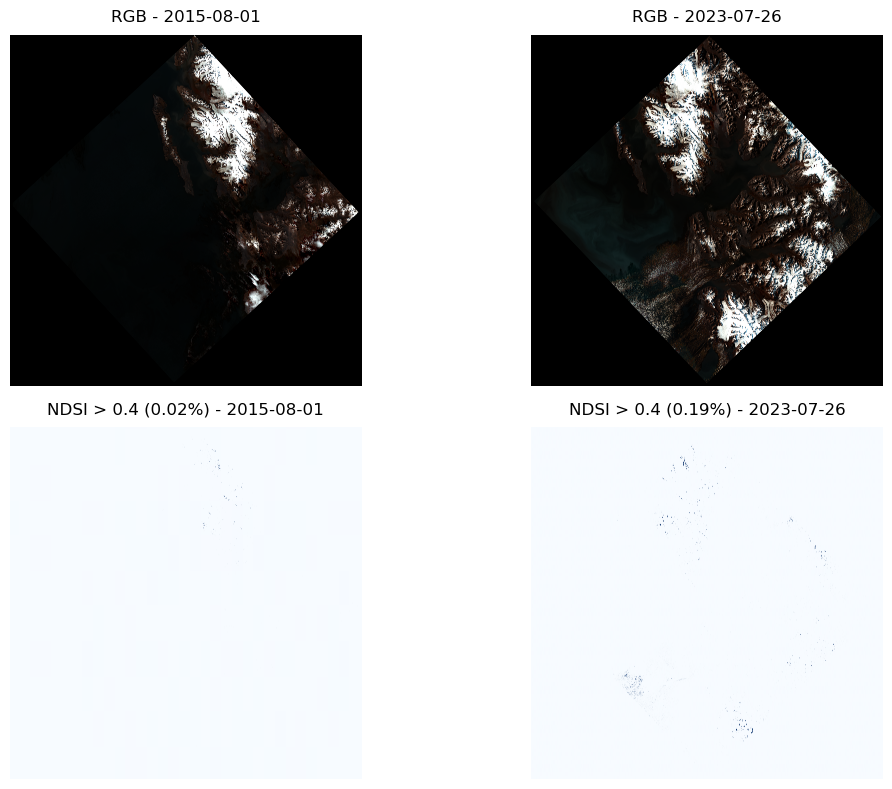

In [13]:
date_old = str(rc_old[0]["StdTime"])[:10]
date_new = str(rc_new[0]["StdTime"])[:10]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# pierwszy wiersz - RGB
axes[0, 0].imshow(rgb_old)
axes[0, 0].set_title(f"RGB - {date_old}", pad=10)
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_new)
axes[0, 1].set_title(f"RGB - {date_new}", pad=10)
axes[0, 1].axis('off')

# drugi wiersz - NDSI
axes[1, 0].imshow(snow_mask_old, cmap='Blues')
axes[1, 0].set_title(f"NDSI > 0.4 ({pct_snow_old:.2f}%) - {date_old}", pad=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(snow_mask_new, cmap='Blues')
axes[1, 1].set_title(f"NDSI > 0.4 ({pct_snow_new:.2f}%) - {date_new}", pad=10)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#TODO: extent nie jest ten sam, kolory są za bardzo podbite, ale za ciemne, ten wskaźnik nie wyłapuje lodu